In [1]:
import numpy as np
import networkx as nx
import pandas as pd
from tqdm.auto import tqdm
import itertools
import statsmodels.api as sm
import matplotlib.pyplot as plt
from scipy.stats import pearsonr
from networkx.algorithms.d_separation import is_d_separator


/Users/fritzwuterich/Documents/Uni/Causal_inference/Thesis/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Helpers

In [2]:
def markov_blanket_oracle_from_graph(G, observed_nodes, target):

    observed_nodes = list(observed_nodes)

    MB = []

    for v in observed_nodes:
        if v == target:
            continue

        conditioning_set = set(
            node for node in observed_nodes
            if node not in [target, v]
        )

        separated = is_d_separator(
            G,
            {target},
            {v},
            conditioning_set
        )

        if not separated:
            MB.append(v)

    return sorted(MB)

In [3]:
def estimate_true_linear_effect(
    graph_info,
    x="X",
    y="Y",
    x0=-1.0,
    x1=1.0,
):
    """
    Compute the exact linear causal effect contrast:

        E[Y | do(X=x1)] - E[Y | do(X=x0)]

    For the linear SCM X = B^T X + eps, the total effect matrix is
    (I - B)^(-1). Entry [x, y] gives the total effect of X on Y per
    one-unit intervention on X.
    """
    order = graph_info["order"]
    B = graph_info["B"].loc[order, order].to_numpy(dtype=float)
    total_effect_matrix = np.linalg.inv(np.eye(len(order)) - B)

    x_idx = order.index(x)
    y_idx = order.index(y)
    effect_per_unit = total_effect_matrix[x_idx, y_idx]

    return float(effect_per_unit * (x1 - x0))


In [4]:
def estimate_effect_linear_adjustment(
    D_obs,
    x="X",
    y="Y",
    Z=None,
    x0=None,
    x1=None,
):
    """
    Estimate a linear adjustment effect using OLS:

        E[Y | do(X=x1)] - E[Y | do(X=x0)] = beta_X * (x1 - x0)
    """
    if Z is None:
        Z = []

    if x0 is None:
        x0 = D_obs[x].quantile(0.25)

    if x1 is None:
        x1 = D_obs[x].quantile(0.75)

    Z = list(Z)
    features = [x] + Z

    X_design = sm.add_constant(D_obs[features], has_constant="add")
    fitted = sm.OLS(D_obs[y], X_design).fit()

    return float(fitted.params[x] * (x1 - x0))


In [5]:
def oracle_independent(X, Y, Z, graph_info):
    """
    Return True iff X and Y are d-separated by Z in the true DAG.
    """
    return is_d_separator(
        graph_info["G"],
        {X},
        {Y},
        set(Z),
    )


In [6]:
def r1(w, Z, graph_info, x='X', y='Y'):
    Z = list(Z)
    Z_plus_x = Z + [x]

    dep_w_y_given_z = not oracle_independent(w, y, Z, graph_info)
    indep_w_y_given_zx = oracle_independent(w, y, Z_plus_x, graph_info)

    return {
        "R1": dep_w_y_given_z and indep_w_y_given_zx,
        "w": w,
        "Z": list(Z),
        "dep_w_y_given_Z": dep_w_y_given_z,
        "indep_w_y_given_Z_plus_x": indep_w_y_given_zx,
    }


In [7]:
def r2(w, Z, graph_info, x='X', y='Y'):
    Z = list(Z)

    dep_w_x_given_z = not oracle_independent(w, x, Z, graph_info)
    indep_w_y_given_z = oracle_independent(w, y, Z, graph_info)

    return {
        "R2": dep_w_x_given_z and indep_w_y_given_z,
        "w": w,
        "Z": list(Z),
        "dep_w_x_given_Z": dep_w_x_given_z,
        "indep_w_y_given_Z": indep_w_y_given_z,
    }


In [8]:
def r2a(Z, graph_info, x='X', y='Y'):
    Z = list(Z)
    indep_x_y_given_z = oracle_independent(x, y, Z, graph_info)

    return {
        "R2a": indep_x_y_given_z,
        "Z": list(Z),
        "indep_x_y_given_Z": indep_x_y_given_z,
    }


In [9]:
def simulate_linear_scm(
    graph_info,
    n,
    rng=None,
    noise_scale=1.0,
    intervention=None,
    return_full=False,
):
    """
    Simulate data from a linear SCM:

        X_i = sum_{j in Pa(i)} b_{ji} X_j + epsilon_i
    """
    if rng is None:
        rng = np.random.default_rng()

    if intervention is None:
        intervention = {}

    order = graph_info["order"]
    observed_nodes = graph_info["observed_nodes"]
    B = graph_info["B"]

    noise = pd.DataFrame(
        rng.normal(0, noise_scale, size=(n, len(order))),
        columns=order,
    )

    D_full = pd.DataFrame(0.0, index=np.arange(n), columns=order)

    for node in order:
        if node in intervention:
            D_full[node] = intervention[node]
            continue

        parents = B.index[B[node] != 0].tolist()

        if len(parents) == 0:
            D_full[node] = noise[node].values
        else:
            parent_values = D_full[parents].to_numpy(dtype=float)
            coeffs = B.loc[parents, node].to_numpy(dtype=float)
            D_full[node] = parent_values @ coeffs + noise[node].values

    D_obs = D_full[observed_nodes].copy()

    if return_full:
        return D_obs, D_full

    return D_obs


## Generate synthetic data

In [ ]:
def generate_random_linear_dataset(
    n,
    rng=None,
    n_obs=10,
    n_latent=0,
    p=0.10,
    treatment="X",
    outcome="Y",
    force_effect=True,
    noise_scale=1.0,
    coefficient_low=0.5,
    coefficient_high=1.5,
    signed_coefficients=False,
    return_full=False,
):

    if rng is None:
        rng = np.random.default_rng()


    latent_nodes = [f"U{i}" for i in range(n_latent)]
    observed_covariates = [f"V{i}" for i in range(n_obs)]

    background_nodes = latent_nodes + observed_covariates
    background_order = list(background_nodes)
    rng.shuffle(background_order)

    order = background_order + [treatment, outcome]
    nodes = order.copy()
    observed_nodes = observed_covariates + [treatment, outcome]

    B = pd.DataFrame(0.0, index=nodes, columns=nodes)
    edges = []

    def sample_coeff():
        coeff = rng.uniform(coefficient_low, coefficient_high)
        if signed_coefficients and rng.random() < 0.5:
            coeff *= -1
        return coeff

    for i, parent in enumerate(order):
        for child in order[i + 1:]:

            if parent == treatment and child == outcome:
                if force_effect is True:
                    add_edge = True
                elif force_effect is False:
                    add_edge = False
                else:
                    add_edge = rng.random() < p
            else:
                add_edge = rng.random() < p

            if add_edge:
                edges.append((parent, child))
                B.loc[parent, child] = sample_coeff()

    G = nx.DiGraph()
    G.add_nodes_from(nodes)
    G.add_edges_from(edges)

    isolated_nodes = [node for node in nodes if G.degree(node) == 0]
    isolated_observed_nodes = [node for node in observed_nodes if G.degree(node) == 0]

    has_direct_effect = G.has_edge(treatment, outcome)
    has_total_effect_path = nx.has_path(G, treatment, outcome)


    actual_MB_x = markov_blanket_oracle_from_graph(
        G=G,
        observed_nodes=observed_nodes,
        target=treatment
    )

    actual_MB_y = markov_blanket_oracle_from_graph(
        G=G,
        observed_nodes=observed_nodes,
        target=outcome
    )

    graph_info = {
        "nodes": nodes,
        "observed_nodes": observed_nodes,
        "latent_nodes": latent_nodes,
        "order": order,
        "edges": edges,
        "B": B,
        "G": G,
        "p": p,
        "n_obs": n_obs,
        "n_latent": n_latent,
        "isolated_nodes": isolated_nodes,
        "isolated_observed_nodes": isolated_observed_nodes,
        "n_isolated_nodes": len(isolated_nodes),
        "n_isolated_observed_nodes": len(isolated_observed_nodes),
        "has_direct_effect": has_direct_effect,
        "has_total_effect_path": has_total_effect_path,
        "actual_MB_x": actual_MB_x,
        "actual_MB_y": actual_MB_y,
    }

    D_obs, D_full = simulate_linear_scm(
        graph_info=graph_info,
        n=n,
        rng=rng,
        noise_scale=noise_scale,
        return_full=True,
    )

    x0 = D_obs[treatment].quantile(0.25)
    x1 = D_obs[treatment].quantile(0.75)

    true_ce = estimate_true_linear_effect(
        graph_info=graph_info,
        x=treatment,
        y=outcome,
        x0=x0,
        x1=x1,
    )

    graph_info["x0"] = x0
    graph_info["x1"] = x1
    graph_info["noise_scale"] = noise_scale
    graph_info["coefficient_low"] = coefficient_low
    graph_info["coefficient_high"] = coefficient_high
    graph_info["signed_coefficients"] = signed_coefficients

    if return_full:
        return D_obs, D_full, B, true_ce, graph_info

    return D_obs, B, true_ce, graph_info


## Main Algorithms

### EHS

In [11]:
def alg_EHS(D_obs, graph_info, x='X', y='Y', max_z_size=None):
    W = [col for col in D_obs.columns if col not in [x, y]]
    if max_z_size is None:
        max_z_size = len(W)

    VASs = []
    R1_count = 0
    R2_count = 0
    R2a_count = 0
    CI_num = 0

    # R2a
    for k in range(max_z_size + 1):
        for Z in itertools.combinations(W, k):
            Z = list(Z)

            out_r2a = r2a(Z, graph_info, x=x, y=y)
            CI_num += 1

            if out_r2a["R2a"]:
                R2_count += 1
                R2a_count += 1

    # R1 and R2b
    for k in range(max_z_size + 1):
        for Z in itertools.combinations(W, k):
            Z = list(Z)
            for w in W:
                if w in Z:
                    continue

                out_r1 = r1(w, Z, graph_info, x, y)
                CI_num += 2

                if out_r1["R1"]:
                    R1_count += 1
                    if Z not in VASs:
                        VASs.append(Z)

                out_r2 = r2(w, Z, graph_info, x, y)
                CI_num += 2

                if out_r2["R2"]:
                    R2_count += 1

    if R1_count > 0 and R2_count > 0:
        decision = '?'
        ate = None
    elif R1_count > 0:
        ates = [estimate_effect_linear_adjustment(D_obs, x, y, Z) for Z in VASs]
        ate = float(np.mean(ates)) if len(ates) > 0 else None
        decision = '+'
    elif R2_count > 0:
        decision = '0'
        ate = 0.0
    else:
        decision = '?'
        ate = None

    return {
        "decision": decision,
        "VASs": VASs,
        "ATE": ate,
        "CI_num": CI_num,
        "R1_count": R1_count,
        "R2_count": R2_count,
        "R2a_count": R2a_count,
    }


### LPC-ID

In [12]:
def alg_lpc_id_oracle(D_obs, graph_info, x='X', y='Y', max_z_size=None):

    observed_nodes = D_obs.columns.tolist()
    W = [node for node in observed_nodes if node not in [x, y]]

    skeleton = nx.Graph()
    skeleton.add_nodes_from(observed_nodes)

    for i, a in enumerate(skeleton.nodes):
        for b in list(skeleton.nodes)[i+1:]:
            skeleton.add_edge(a, b)

    ci_cache = {}
    sepsets = {}

    r1_hits = []
    r2_hits = []

    n_ci_requests = 0
    n_ci_executed = 0
    r1_count = 0
    r2_count = 0

    if max_z_size is None:
        max_z_size = len(skeleton.nodes) - 2
    else:
        max_z_size = min(max_z_size, len(skeleton.nodes) - 2)

    def cached_independent(A, B, Z):
        nonlocal n_ci_requests, n_ci_executed
        Z = tuple(sorted(Z))
        key = (A, B, Z)
        n_ci_requests += 1

        if key not in ci_cache:
            n_ci_executed += 1
            indep = oracle_independent(A, B, list(Z), graph_info)
            ci_cache[key] = indep
            ci_cache[(B, A, Z)] = indep

        return ci_cache[key]

    for l in range(max_z_size + 1):

        deg_x_local = len([n for n in skeleton.neighbors(x) if n != y])
        deg_y_local = len([n for n in skeleton.neighbors(y) if n != x])

        if l > max(deg_x_local, deg_y_local):
            break

        any_test_possible_this_round = False
        pairs_to_check = list(skeleton.edges())

        for A, B in pairs_to_check:
            if not skeleton.has_edge(A, B):
                continue

            adjA = [n for n in skeleton.neighbors(A) if n != B]
            adjB = [n for n in skeleton.neighbors(B) if n != A]

            if len(adjA) < l and len(adjB) < l:
                continue

            any_test_possible_this_round = True

            candidate_sets = set()

            if len(adjA) >= l:
                for Z in itertools.combinations(adjA, l):
                    candidate_sets.add(tuple(sorted(Z)))

            if len(adjB) >= l:
                for Z in itertools.combinations(adjB, l):
                    candidate_sets.add(tuple(sorted(Z)))

            for Z in candidate_sets:
                Z = tuple(sorted(Z))
                indep = cached_independent(A, B, Z)

                pair_is_xy = set([A, B]) == set([x, y])
                pair_is_wy = ((A in W and B == y) or (B in W and A == y))
                pair_is_wx = ((A in W and B == x) or (B in W and A == x))

                # Standard PC skeleton update
                if indep and skeleton.has_edge(A, B):
                    skeleton.remove_edge(A, B)
                    sepsets[frozenset([A, B])] = list(Z)

                # R2a
                if pair_is_xy and indep:
                    r2_count += 1
                    r2_hits.append({
                        "reason": "R2a",
                        "Z": list(Z)
                    })

                # R1 hook
                if pair_is_wy and (not indep) and (x not in Z):
                    w = A if A in W else B

                    if w not in Z and y not in Z:
                        Z_plus_x = tuple(sorted(list(Z) + [x]))
                        indep_followup = cached_independent(w, y, Z_plus_x)

                        if indep_followup:
                            r1_count += 1
                            r1_hits.append({
                                "reason": "R1",
                                "w": w,
                                "Z": list(Z)
                            })

                # R2 hook from cache
                if pair_is_wy and indep:
                    w = A if A in W else B
                    key_wx = (w, x, Z)

                    if key_wx in ci_cache and ci_cache[key_wx] is False:
                        r2_count += 1
                        r2_hits.append({
                            "reason": "R2",
                            "w": w,
                            "Z": list(Z)
                        })

                if pair_is_wx and (not indep):
                    w = A if A in W else B
                    key_wy = (w, y, Z)

                    if key_wy in ci_cache and ci_cache[key_wy] is True:
                        r2_count += 1
                        r2_hits.append({
                            "decision": "0",
                            "reason": "R2",
                            "w": w,
                            "Z": list(Z)
                        })

        if not any_test_possible_this_round:
            break

    # Run remaining LSAS-style oracle tests
    Ne_x = set(skeleton.neighbors(x))
    Ne_y = set(skeleton.neighbors(y))

    MB_y = sorted(Ne_y - {x})
    MB_x = sorted((Ne_x | Ne_y) - {x, y})

    for z_size in range(len(MB_y) + 1):
        for Z in itertools.combinations(MB_y, z_size):
            Z = tuple(sorted(Z))

            if cached_independent(x, y, Z):
                r2_count += 1
                r2_hits.append({
                    "reason": "R2a_LSAS_completion",
                    "Z": list(Z)
                })

    for w in MB_x:
        MB_y_without_w = [node for node in MB_y if node != w]
        for z_size in range(len(MB_y_without_w) + 1):
            for Z in itertools.combinations(MB_y_without_w, z_size):
                Z = tuple(sorted(Z))

                indep_wy = cached_independent(w, y, Z)

                if not indep_wy:
                    Z_plus_x = tuple(sorted(list(Z) + [x]))
                    indep_wy_x = cached_independent(w, y, Z_plus_x)

                    if indep_wy_x:
                        r1_count += 1
                        r1_hits.append({
                            "reason": "R1_LSAS_completion",
                            "w": w,
                            "Z": list(Z)
                        })

                indep_wx = cached_independent(w, x, Z)
                indep_wy = cached_independent(w, y, Z)

                if (not indep_wx) and indep_wy:
                    r2_count += 1
                    r2_hits.append({
                        "reason": "R2b_LSAS_completion",
                        "w": w,
                        "Z": list(Z)
                    })

    if len(r1_hits) > 0 and len(r2_hits) > 0:
        decision = "?"
        vas_list = [hit["Z"] for hit in r1_hits]
        ate = None

    elif len(r1_hits) > 0:
        decision = "+"
        vas_list = []

        for hit in r1_hits:
            if hit["Z"] not in vas_list:
                vas_list.append(hit["Z"])

        ates = [estimate_effect_linear_adjustment(D_obs, x=x, y=y, Z=Z) for Z in vas_list]
        ate = float(np.mean(ates)) if len(ates) > 0 else None

    elif len(r2_hits) > 0:
        decision = "0"
        vas_list = []
        ate = 0.0

    else:
        decision = "?"
        vas_list = []
        ate = None

    return {
        "decision": decision,
        "VASs": vas_list,
        "ATE": ate,
        "CI_num": n_ci_requests,
        "CI_num_executed": n_ci_executed,
        "R1_count": r1_count,
        "R2_count": r2_count,
        "r1_hits": r1_hits,
        "r2_hits": r2_hits,
        "sepsets": sepsets,
        "MB_x": MB_x,
        "MB_y": MB_y,
    }


### LSAS

In [ ]:
def alg_LSAS_oracle(
    D_obs,
    graph_info,
    x="X",
    y="Y",
    max_z_size=None,
):

    observed_nodes = D_obs.columns.tolist()
    V = observed_nodes.copy()

    MB_x = []
    MB_y = []

    CI_num = 0
    r1_hits = []
    r2_hits = []

    # Markov blanket discovery by total conditioning
    for Vi in V:
        if Vi == x:
            continue

        cond_set = [node for node in V if node not in [x, Vi]]
        CI_num += 1

        if not oracle_independent(x, Vi, cond_set, graph_info):
            MB_x.append(Vi)

    for Vi in V:
        if Vi == y:
            continue

        cond_set = [node for node in V if node not in [y, Vi]]
        CI_num += 1

        if not oracle_independent(y, Vi, cond_set, graph_info):
            MB_y.append(Vi)

    S_candidates = [s for s in MB_x if s != y]
    Z_candidates = [z for z in MB_y if z != x]

    if max_z_size is None:
        max_z_size = len(Z_candidates)
    else:
        max_z_size = min(max_z_size, len(Z_candidates))

    # Local LSAS search over S and Z
    for k in range(max_z_size + 1):
        for Z_tuple in itertools.combinations(Z_candidates, k):
            Z = list(Z_tuple)

            # R2a: X independent of Y given Z
            CI_num += 1
            indep_xy = oracle_independent(x, y, Z, graph_info)

            if indep_xy:
                r2_hits.append({
                    "reason": "R2a",
                    "Z": Z,
                })

            for S in S_candidates:
                if S in Z:
                    continue

                # R1 first condition: S dependent with Y given Z
                CI_num += 1
                dep_sy_z = not oracle_independent(S, y, Z, graph_info)

                # R1 second condition: S independent of Y given Z union {X}
                CI_num += 1
                indep_sy_zx = oracle_independent(S, y, Z + [x], graph_info)

                if dep_sy_z and indep_sy_zx:
                    r1_hits.append({
                        "reason": "R1",
                        "S": S,
                        "Z": Z,
                    })

                # R2b first condition: S dependent with X given Z
                CI_num += 1
                dep_sx_z = not oracle_independent(S, x, Z, graph_info)

                # R2b second condition: S independent of Y given Z
                indep_sy_z_for_r2 = not dep_sy_z

                if dep_sx_z and indep_sy_z_for_r2:
                    r2_hits.append({
                        "reason": "R2b",
                        "S": S,
                        "Z": Z,
                    })

    if len(r2_hits) > 0:
        decision = "0"
        vas_list = []
        ate = 0.0

    elif len(r1_hits) > 0:
        decision = "+"

        vas_list = []
        for hit in r1_hits:
            if hit["Z"] not in vas_list:
                vas_list.append(hit["Z"])

        ates = [
            estimate_effect_linear_adjustment(
                D_obs,
                x=x,
                y=y,
                Z=Z,
            )
            for Z in vas_list
        ]

        ate = float(np.mean(ates)) if len(ates) > 0 else None

    else:
        decision = "?"
        vas_list = []
        ate = None

    return {
        "decision": decision,
        "VASs": vas_list,
        "ATE": ate,
        "CI_num": CI_num,
        "R1_count": len(r1_hits),
        "R2_count": len(r2_hits),
        "r1_hits": r1_hits,
        "r2_hits": r2_hits,
        "MB_x": MB_x,
        "MB_y": MB_y,
        "S_candidates": S_candidates,
        "Z_candidates": Z_candidates,
    }


# Run Experiment

In [14]:
def run_structure_experiment(
    structure_name,
    sample_sizes=[1000, 5000, 10000, 15000],
    n_reps=100,
    treatment="treatment",
    outcome="outcome",
    effect_mode="balanced",    # "positive", "zero", "balanced", or "random"
    n_obs=15,
    n_latent=0,
    p=0.1,
    noise_scale=1.0,
    coefficient_low=0.5,
    coefficient_high=1.5,
    ehs_max_z_size=None,
    local_max_z_size=None,
):
    results = []

    for n in sample_sizes:
        tqdm.write(f"Running {structure_name} with sample size {n} for {n_reps} reps...")

        for rep in tqdm(range(n_reps), desc=f"Processing {structure_name}", leave=True, position=0):

            rng = np.random.default_rng(rep)

            if effect_mode == "positive":
                force_effect = True
            elif effect_mode == "zero":
                force_effect = False
            elif effect_mode == "balanced":
                force_effect = (rep % 2 == 0)
            elif effect_mode == "random":
                force_effect = bool(rng.integers(0, 2))
            else:
                raise ValueError("effect_mode must be 'positive', 'zero', 'balanced', or 'random'")

            D_obs, B, true_ce, graph_info = generate_random_linear_dataset(
                n,
                rng,
                n_obs=n_obs,
                n_latent=n_latent,
                p=p,
                treatment=treatment,
                outcome=outcome,
                force_effect=force_effect,
                noise_scale=noise_scale,
                coefficient_low=coefficient_low,
                coefficient_high=coefficient_high,
            )

            graph_decision = "+" if graph_info["has_total_effect_path"] else "0"

            method_results = []

            # -------- EHS --------
            # res_ehs = alg_EHS(
            #     D_obs,
            #     graph_info,
            #     x=treatment,
            #     y=outcome,
            #     max_z_size=ehs_max_z_size,
            # )
            # method_results.append(("EHS", res_ehs, res_ehs["CI_num"]))

            # -------- LPC-ID --------
            res_lpc_id = alg_lpc_id_oracle(
                D_obs,
                graph_info,
                x=treatment,
                y=outcome,
                max_z_size=local_max_z_size,
            )
            method_results.append(("LPC-ID", res_lpc_id, res_lpc_id["CI_num_executed"]))

            # -------- LSAS --------
            res_lsas = alg_LSAS_oracle(
                D_obs,
                graph_info,
                x=treatment,
                y=outcome,
                max_z_size=local_max_z_size,
            )
            method_results.append(("LSAS", res_lsas, res_lsas["CI_num"]))

            for method, res, n_tests in method_results:
                decision = res["decision"]
                estimated_ce = res["ATE"]

                if decision != "?" and estimated_ce is not None and abs(true_ce):
                    RE = abs(estimated_ce - true_ce) / max(1e-12, abs(true_ce))
                else:
                    RE = np.nan

                results.append({
                    "method": method,
                    "structure": structure_name,
                    "sample_size": n,
                    "rep": rep,
                    "graph_decision": graph_decision,
                    "decision": decision,
                    "decision_matches_graph": decision == graph_decision,
                    "is_decisive": decision != "?",
                    "is_sound_decisive": (decision == "?") or (decision == graph_decision),
                    "true_ce": true_ce,
                    "estimated_ce": estimated_ce,
                    "RE": RE,
                    "nTest": n_tests,
                    "VASs": res["VASs"],
                    "R1_count": res["R1_count"],
                    "R2_count": res["R2_count"],
                    "p_graph": graph_info["p"],
                    "n_obs": graph_info["n_obs"],
                    "n_latent": graph_info["n_latent"],
                    "n_isolated_observed_nodes": graph_info["n_isolated_observed_nodes"],
                    "has_direct_effect": graph_info["has_direct_effect"],
                    "has_total_effect_path": graph_info["has_total_effect_path"],
                    "MB_x": res.get("MB_x"),
                    "MB_y": res.get("MB_y"),
                    "actual_MB_x": graph_info["actual_MB_x"],
                    "actual_MB_y": graph_info["actual_MB_y"],
                    "p": p,
                    "noise_scale": noise_scale,
                })

    return pd.DataFrame(results)


In [15]:
results = run_structure_experiment(
    structure_name="Random Graphs",
    sample_sizes=[1000, 5000, 10000, 15000],
    n_reps=100,
    n_obs=30,
    ehs_max_z_size=None,
    local_max_z_size=None,
)


Running Random Graphs with sample size 1000 for 100 reps...


Processing Random Graphs: 100%|██████████| 100/100 [02:59<00:00,  1.79s/it]


Running Random Graphs with sample size 5000 for 100 reps...


Processing Random Graphs: 100%|██████████| 100/100 [02:59<00:00,  1.79s/it]


Running Random Graphs with sample size 10000 for 100 reps...


Processing Random Graphs: 100%|██████████| 100/100 [02:59<00:00,  1.80s/it]


Running Random Graphs with sample size 15000 for 100 reps...


Processing Random Graphs: 100%|██████████| 100/100 [02:59<00:00,  1.79s/it]


## Metrics

### Oracle Decisions


In [16]:
decision_counts = results.groupby(["method", "sample_size", "decision"]).size()
decision_counts

method  sample_size  decision
LPC-ID  1000         +           47
                     0           50
                     ?            3
        5000         +           47
                     0           50
                     ?            3
        10000        +           47
                     0           50
                     ?            3
        15000        +           47
                     0           50
                     ?            3
LSAS    1000         +           47
                     0           50
                     ?            3
        5000         +           47
                     0           50
                     ?            3
        10000        +           47
                     0           50
                     ?            3
        15000        +           47
                     0           50
                     ?            3
dtype: int64

In [17]:
summary = (
    results
    .groupby(['method', "sample_size"], as_index=False)
    .agg(
        mean_RE=("RE", "mean"),
        std_RE=("RE", "std"),
        mean_nTest=("nTest", "mean"),
        std_nTest=("nTest", "std"),
        graph_match_rate=("decision_matches_graph", "mean"),
        coverage=("is_decisive", "mean"),
        n_reps=("decision", "size")
    )
)

summary


,method,sample_size,mean_RE,std_RE,mean_nTest,std_nTest,graph_match_rate,coverage,n_reps
0,LPC-ID,1000,0.020960,0.033400,40722.02,47025.566913,0.97,0.97,100
1,LPC-ID,5000,0.008583,0.015084,40722.02,47025.566913,0.97,0.97,100
2,LPC-ID,10000,0.007084,0.008921,40722.02,47025.566913,0.97,0.97,100
3,LPC-ID,15000,0.007875,0.013816,40722.02,47025.566913,0.97,0.97,100
4,LSAS,1000,0.014035,0.022030,315.63,589.013293,0.97,0.97,100
5,LSAS,5000,0.005528,0.007800,315.63,589.013293,0.97,0.97,100
6,LSAS,10000,0.003592,0.004379,315.63,589.013293,0.97,0.97,100
7,LSAS,15000,0.003810,0.004927,315.63,589.013293,0.97,0.97,100


In [18]:
decisive_summary = (
    results[results["is_decisive"]]
    .groupby(["method", "sample_size"])
    .agg(
        soundness=("decision_matches_graph", "mean"),
        n_decisive=("decision", "size"),
    )
    .reset_index()
)

summary = summary.merge(
    decisive_summary,
    on=["method", "sample_size"],
    how="left"
)


In [19]:
summary["graph_match_pct"] = 100 * summary["graph_match_rate"]
summary["coverage_pct"] = 100 * summary["coverage"]
summary["soundness_pct"] = 100 * summary["soundness"]
summary[
    [
        "method",
        "sample_size",
        "graph_match_pct",
        "coverage_pct",
        "soundness_pct",
        "n_reps",
        "n_decisive",
    ]
]

overall_decision_summary = (
    results
    .groupby("method")
    .agg(
        graph_match_rate=("decision_matches_graph", "mean"),
        coverage=("is_decisive", "mean"),
        n_reps=("decision", "size"),
    )
    .reset_index()
)

overall_decisive_summary = (
    results[results["is_decisive"]]
    .groupby("method")
    .agg(
        soundness=("decision_matches_graph", "mean"),
        n_decisive=("decision", "size"),
    )
    .reset_index()
)

overall_decision_summary = overall_decision_summary.merge(
    overall_decisive_summary,
    on="method",
    how="left"
)

overall_decision_summary


,method,graph_match_rate,coverage,n_reps,soundness,n_decisive
0,LPC-ID,0.97,0.97,400,1.0,388
1,LSAS,0.97,0.97,400,1.0,388


In [20]:
overall_decision_summary["graph_match_pct"] = 100 * overall_decision_summary["graph_match_rate"]
overall_decision_summary["coverage_pct"] = 100 * overall_decision_summary["coverage"]
overall_decision_summary["soundness_pct"] = 100 * overall_decision_summary["soundness"]

overall_decision_summary[
    [
        "method",
        "graph_match_pct",
        "coverage_pct",
        "soundness_pct",
        "n_reps",
        "n_decisive",
    ]
]


,method,graph_match_pct,coverage_pct,soundness_pct,n_reps,n_decisive
0,LPC-ID,97.0,97.0,100.0,400,388
1,LSAS,97.0,97.0,100.0,400,388


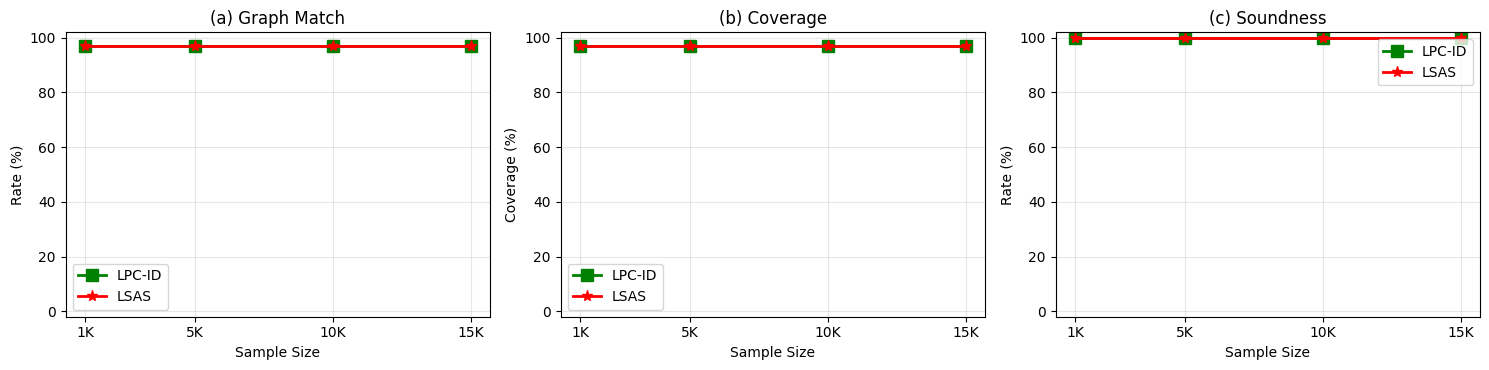

In [21]:
method_styles = {
    "LSAS": {
        "color": "red",
        "marker": "*"
    },
    "EHS": {
        "color": "blue",
        "marker": "o"
    },
    "LPC-ID": {
        "color": "green",
        "marker": "s"
    }
}

fig, axes = plt.subplots(1, 3, figsize=(15, 3.8))

for method in summary["method"].unique():
    df_method = summary[summary["method"] == method]

    style = method_styles.get(
        method,
        {"color": "black", "marker": "o"}
    )

    # Graph match
    axes[0].plot(
        df_method["sample_size"],
        100 * df_method["graph_match_rate"],
        marker=style["marker"],
        color=style["color"],
        linewidth=2,
        markersize=8,
        label=method
    )

    # Coverage
    axes[1].plot(
        df_method["sample_size"],
        100 * df_method["coverage"],
        marker=style["marker"],
        color=style["color"],
        linewidth=2,
        markersize=8,
        label=method
    )

    # Soundness among decisive outputs
    axes[2].plot(
        df_method["sample_size"],
        100 * df_method["soundness"],
        marker=style["marker"],
        color=style["color"],
        linewidth=2,
        markersize=8,
        label=method
    )

unique_sample_sizes = sorted(summary["sample_size"].unique())
sample_labels = [str(n) if n < 1000 else f"{n//1000}K" for n in unique_sample_sizes]

for ax in axes:
    ax.set_xlabel("Sample Size")
    ax.set_xticks(unique_sample_sizes)
    ax.set_xticklabels(sample_labels)
    ax.set_ylim(-2, 102)
    ax.grid(alpha=0.3)
    ax.legend()

axes[0].set_ylabel("Rate (%)")
axes[0].set_title("(a) Graph Match")

axes[1].set_ylabel("Coverage (%)")
axes[1].set_title("(b) Coverage")

axes[2].set_ylabel("Rate (%)")
axes[2].set_title("(c) Soundness")

plt.tight_layout()
plt.show()


In [22]:
pd.crosstab(
    results["graph_decision"],
    results["decision"],
    rownames=["graph"],
    colnames=["algorithm"],
    normalize="index"
)


algorithm,+,0,?
graph,,,
+,0.94,0.0,0.06
0,0.00,1.0,0.00


### Relative Error and Test Counts

- `RE` is computed for decisive outputs with an available effect estimate.
- `nTest` is the number of oracle d-separation queries.


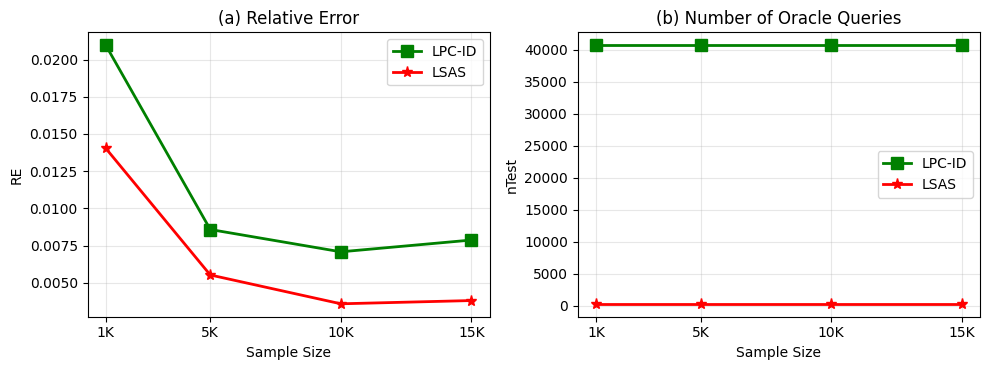

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(10, 3.8))

for method in summary["method"].unique():
    df_method = summary[summary["method"] == method]

    style = method_styles.get(
        method,
        {"color": "black", "marker": "o"}
    )

    # RE 
    axes[0].plot(
        df_method["sample_size"],
        df_method["mean_RE"],
        marker=style["marker"],
        color=style["color"],
        linewidth=2,
        markersize=8,
        label=method
    )

    # nTest 
    axes[1].plot(
        df_method["sample_size"],
        df_method["mean_nTest"],
        marker=style["marker"],
        color=style["color"],
        linewidth=2,
        markersize=8,
        label=method
    )

unique_sample_sizes = sorted(summary["sample_size"].unique())
sample_labels = [str(n) if n < 1000 else f"{n//1000}K" for n in unique_sample_sizes]

axes[0].set_xlabel("Sample Size")
axes[0].set_ylabel("RE")
axes[0].set_title("(a) Relative Error")
axes[0].set_xticks(unique_sample_sizes)
axes[0].set_xticklabels(sample_labels)
axes[0].grid(alpha=0.3)
axes[0].legend()

axes[1].set_xlabel("Sample Size")
axes[1].set_ylabel("nTest")
axes[1].set_title("(b) Number of Oracle Queries")
axes[1].set_xticks(unique_sample_sizes)
axes[1].set_xticklabels(sample_labels)
axes[1].grid(alpha=0.3)
axes[1].legend()

plt.tight_layout()
plt.show()